,Strategy,Avg_Original_Tokens,Avg_Optimized_Tokens,Avg_Token_Reduction_Percent,Avg_Original_Cost,Avg_Optimized_Cost,Avg_Cost_Reduction_Percent,Avg_Quality_Score,Tests_Count,Combined_Score,Best Strategy?
0,domain_aware,141.000000,122.000000,13.48%,141.000000,122.000000,6.30%,0.744,1,31.756000,Yes
1,improved_aggressive,98.500000,84.750000,13.82%,98.500000,84.750000,5.31%,0.704,4,30.783000,
2,length_aware,91.000000,83.000000,8.79%,91.000000,83.000000,-1.32%,0.619,1,24.723000,


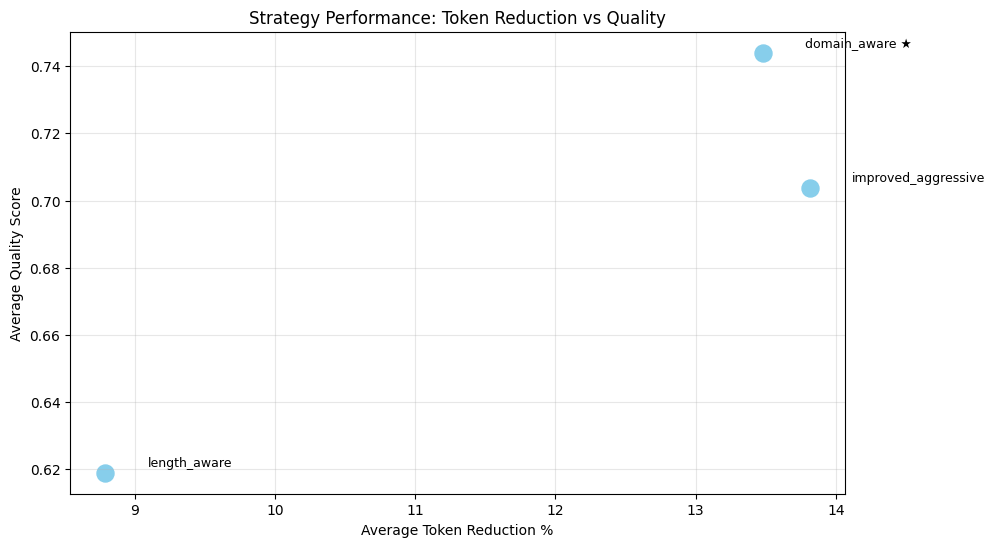

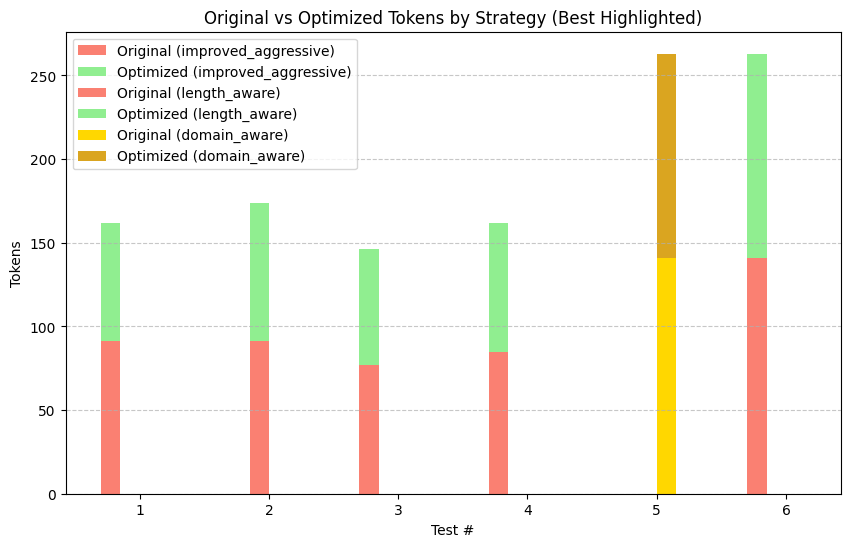

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import json
from IPython.display import display

# load json
json_file = "enhanced_tokengains_results.json"
with open(json_file, "r", encoding="utf-8") as f:
    data = json.load(f)

# covert json to df
records = []
for i, entry in enumerate(data["detailed_results"], start=1):
    records.append({
        "Test #": i,
        "Strategy": entry["strategy"],
        "Original Tokens": entry["original_tokens"],
        "Optimized Tokens": entry["reduced_tokens"],
        "Token Reduction %": round(entry["token_reduction_percent"], 2),
        "Original Cost": entry["original_tokens"],  # Assuming 1 unit per token
        "Optimized Cost": entry["reduced_tokens"],  # Adjust if your cost is different
        "Cost Reduction %": round(entry.get("cost_savings_percent", 0), 2),
        "Quality Score": round(entry["quality_score"], 3)
    })

df = pd.DataFrame(records)

# aggregate stats by strat
agg_df = df.groupby("Strategy").agg(
    Avg_Original_Tokens=("Original Tokens", "mean"),
    Avg_Optimized_Tokens=("Optimized Tokens", "mean"),
    Avg_Token_Reduction_Percent=("Token Reduction %", "mean"),
    Avg_Original_Cost=("Original Cost", "mean"),
    Avg_Optimized_Cost=("Optimized Cost", "mean"),
    Avg_Cost_Reduction_Percent=("Cost Reduction %", "mean"),
    Avg_Quality_Score=("Quality Score", "mean"),
    Tests_Count=("Test #", "count")
).reset_index()

# best stat based on weighted score
agg_df["Combined_Score"] = agg_df["Avg_Token_Reduction_Percent"]*0.7 + agg_df["Avg_Quality_Score"]*30
best_index = agg_df["Combined_Score"].idxmax()
agg_df["Best Strategy?"] = ""
agg_df.loc[best_index, "Best Strategy?"] = "Yes"

best_strategies = {}
for i, row in agg_df.iterrows():
    if row["Best Strategy?"] == "Yes":
        best_strategies[row["Strategy"]] = True

# display styled table
styled_table = agg_df.style \
    .background_gradient(subset=["Avg_Token_Reduction_Percent","Avg_Quality_Score"], cmap="YlGnBu") \
    .highlight_max(subset=["Avg_Token_Reduction_Percent","Avg_Quality_Score"], color="gold") \
    .format({
        "Avg_Token_Reduction_Percent": "{:.2f}%",
        "Avg_Cost_Reduction_Percent": "{:.2f}%",
        "Avg_Quality_Score": "{:.3f}"
    })

display(styled_table)

# token reduction % vs. quality score
plt.figure(figsize=(10,6))
plt.scatter(agg_df["Avg_Token_Reduction_Percent"], agg_df["Avg_Quality_Score"], s=150, c='skyblue')

for i, row in agg_df.iterrows():
    plt.text(row["Avg_Token_Reduction_Percent"]+0.3, row["Avg_Quality_Score"]+0.002,
             f"{row['Strategy']}{' ★' if row['Best Strategy?']=='Yes' else ''}", fontsize=9)

plt.xlabel("Average Token Reduction %")
plt.ylabel("Average Quality Score")
plt.title("Strategy Performance: Token Reduction vs Quality")
plt.grid(alpha=0.3)
plt.show()

# og vs. optimized tokens per strategy 
plt.figure(figsize=(10,6))
bar_width = 0.15
strategies = df["Strategy"].unique()
x = df["Test #"].unique()

for i, strategy in enumerate(strategies):
    strat_df = df[df["Strategy"] == strategy].set_index("Test #")  # index by Test #
    # Align heights with all test #s
    orig_tokens = [strat_df.loc[t, "Original Tokens"] if t in strat_df.index else 0 for t in x]
    opt_tokens  = [strat_df.loc[t, "Optimized Tokens"] if t in strat_df.index else 0 for t in x]

    offset = (i - len(strategies)/2) * bar_width
    color_orig = "gold" if best_strategies.get(strategy, False) else "salmon"
    color_opt = "goldenrod" if best_strategies.get(strategy, False) else "lightgreen"

    plt.bar([xi + offset for xi in x], orig_tokens, width=bar_width, label=f"Original ({strategy})", color=color_orig)
    plt.bar([xi + offset for xi in x], opt_tokens, width=bar_width, bottom=orig_tokens, label=f"Optimized ({strategy})", color=color_opt)

plt.xlabel("Test #")
plt.ylabel("Tokens")
plt.title("Original vs Optimized Tokens by Strategy (Best Highlighted)")
plt.xticks(x)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



